In [13]:
!apt-get update
!apt-get install -y libglu1-mesa
%pip install numpy matplotlib meshio pygmsh pyvista anywidget
%pip install --upgrade meshio

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libglu1-mesa is already the newest version (9.0.2-1).
0 upgraded, 0 newly installed, 0 to remo

LLMへの指示
ルールの指定
作成したい形状

In [ ]:
rules_content = """# pygmsh.occ Geometry Generation Rules (Strict)

You are a CAD/CAE expert. Output ONLY valid Python code using the `pygmsh.occ` API.
The variable `geom` is already initialized.

### 1. Mandatory API Signatures:
- Rectangle: `rect = geom.add_rectangle([x0, y0, z0], width, height)`
- Disk (Circle): `disk = geom.add_disk([xc, yc, zc], radius)`
- Boolean Union: `union = geom.boolean_union([entity1, entity2, ...])`
- Boolean Difference: `diff = geom.boolean_difference(target_entity, tool_entity)`

### 2. Code Structure & Formatting (ULTRA STRICT):
- **Comment Every Line**: Every single line of code MUST include a descriptive comment starting with '#' on the same line.
- **Strict Single-Statement Lines**: Each line MUST contain exactly one statement (assignment or function call). Combining statements is strictly forbidden.
- **NO Multi-variable Assignments**: You MUST NOT define multiple variables on one line (e.g., NO `W, H = 500.0, 200.0`). Define each variable on its own separate line.
- **Mandatory Physical Spacing**: You MUST insert at least one blank line (empty line) between every single valid line of code to ensure physical separation.
- **NO Semicolons**: Semicolons (;) are strictly forbidden for separating or ending statements.
- **Float Only**: Use float values for all dimensions (e.g., 50.0).

### 3. Output Format:
- **No Markdown**: Do NOT use code blocks (```). Start directly with Python code.
- **No Explanation**: Output ONLY the code and comments. No conversational text or preamble.
- **Final Variable**: Assign the final resulting shape to a variable named `final_shape`.

### 4. Physical Groups:
- **Surface**: Always apply `geom.add_physical(final_shape, "SURFACE")`.
- **Boundaries**: To define a boundary (e.g., "left edge"), create a very thin rectangle (0.1 thickness) and label it (e.g., "FIXED_SUPPORT").

### 5. Mesh Stability:
- Avoid overlapping edges to prevent kernel errors.
- Ensure all holes and cutouts are completely contained within the base plate boundaries.

### 6. Correct Style Example (Follow this exactly):
W = 800.0  # Define width

H = 300.0  # Define height

plate = geom.add_rectangle([0.0, 0.0, 0.0], W, H)  # Create base plate

geom.add_physical(plate, "SURFACE")  # Assign surface group
"""

# ファイルとして保存
with open("pygmsh_rules.txt", "w", encoding="utf-8") as f:
    f.write(rules_content)

print("✅ 'pygmsh_rules.txt' has been created successfully.")

以下メッシュ作成

In [14]:
import pygmsh
import numpy as np
import matplotlib.pyplot as plt
import json

# 設定
OUTPUT_FILE = 'input.json'

print("✅ Libraries loaded.")

✅ Libraries loaded.


LLMのプロンプトからメッシュ生成

In [ ]:
def generate_mesh_from_llm(recipe_code, mesh_size=10.0):

    try:
        with pygmsh.occ.Geometry() as geom:
            # メッシュサイズのグローバル設定
            geom.characteristic_length_min = mesh_size
            geom.characteristic_length_max = mesh_size

            # LLMが生成したコードを実行
            # 第2引数に、exec内で使用可能にする変数を辞書で渡します
            exec_globals = {"geom": geom}
            exec(recipe_code, exec_globals)

            # メッシュ生成
            mesh = geom.generate_mesh()
            return mesh

    except Exception as e:
        print(f"❌ Error during mesh generation: {e}")
        return None

User Prompt: 添付した pygmsh_rules.txt のルールを厳守して、以下の形状を作成するPythonコードを出力してください。

要望： 縦300、横800の板の左端を固定したい。中央に三角形のような配置で3つの小さな穴（半径10）を開け、さらに右端の上下の角に小さな切り欠きを作って。

In [16]:
LLM_GEOMETRY_RECIPE = """
W = 700.0                      # 板の横幅（幅）を定義

H = 350.0                      # 板の縦幅（高さ）を定義

plate = geom.add_rectangle([0.0, 0.0, 0.0], W, H)                            # 基本となる長方形板を作成（左下原点）

# --------------------------------------------------------------------------

fix_width = 0.1                # 固定支持領域として使う極薄長方形の幅（メッシュ安定性のため）

fix = geom.add_rectangle([0.0, 0.0, 0.0], fix_width, H)                      # 左端全体を覆う極薄矩形を作成（固定支持用）

geom.add_physical(fix, "FIXED_SUPPORT")                                      # 左端を「FIXED_SUPPORT」物理グループとして登録

# --------------------------------------------------------------------------

r = 12.0                       # 円孔の半径を定義

upper_x = W / 2.0              # 円のX座標（板の中央）

upper_y = H * 0.6              # 上側の円孔（中央よりやや上：高さの60%位置）

lower_y = H * 0.4              # 下側の円孔（中央よりやや下：高さの40%位置）

hole_upper = geom.add_disk([upper_x, upper_y, 0.0], r)                       # 上側の円孔を作成

hole_lower = geom.add_disk([upper_x, lower_y, 0.0], r)                       # 下側の円孔を作成

# --------------------------------------------------------------------------

notch_w = 50.0                 # 右端切り欠きの幅

notch_h = 30.0                 # 右端切り欠きの高さ

notch_x = W - notch_w          # 切り欠きの左下X座標（右端に合わせる）

notch_y = (H - notch_h) / 2.0 # 切り欠きの左下Y座標（上下中央に配置）

notch = geom.add_rectangle([notch_x, notch_y, 0.0], notch_w, notch_h)        # 右端の長方形切り欠き領域を作成

# --------------------------------------------------------------------------

all_holes = geom.boolean_union([hole_upper, hole_lower, notch])              # 2つの円孔と切り欠きを1つのツール形状に統合

final_shape = geom.boolean_difference(plate, all_holes)                      # 基本板からすべての穴・切り欠きを削り取る

geom.add_physical(final_shape, "SURFACE")                                    # 最終形状を「SURFACE」物理グループとして登録
"""


In [17]:

def generate_mesh_from_llm(recipe_code, mesh_size=5.0):
    import pygmsh
    try:
        # 文字列から前後の空白やマークダウンのゴミを取り除く
        clean_code = recipe_code.strip().replace("```python", "").replace("```", "")

        with pygmsh.occ.Geometry() as geom:
            geom.characteristic_length_min = mesh_size
            geom.characteristic_length_max = mesh_size

            # 実行環境にgeomを渡す
            local_vars = {"geom": geom}
            exec(clean_code, {}, local_vars)

            mesh = geom.generate_mesh()
            return mesh
    except Exception as e:
        print(f"❌ Mesh generation failed: {e}")
        return None

In [18]:
# --- この1行を追加 ---
mesh = generate_mesh_from_llm(LLM_GEOMETRY_RECIPE, mesh_size=10.0)

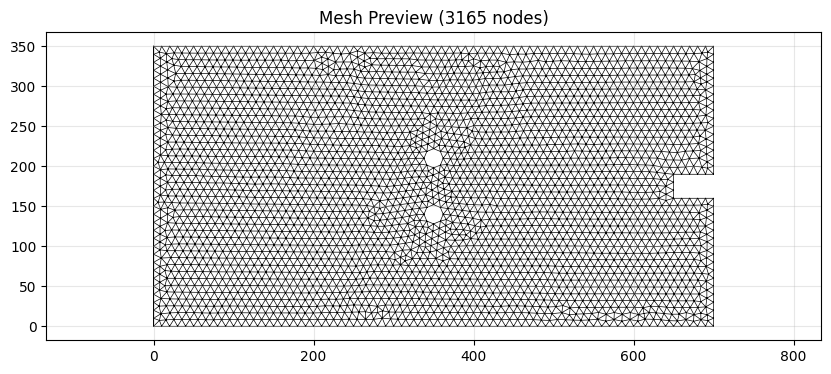

In [19]:
if mesh is not None:
    points = mesh.points
    triangles = mesh.cells_dict["triangle"]

    plt.figure(figsize=(10, 4))
    plt.triplot(points[:, 0], points[:, 1], triangles, lw=0.5, color='k')
    plt.title(f"Mesh Preview ({len(points)} nodes)")
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("⚠️ No mesh to preview.")

In [20]:
# --- 5. 保存（形状データのみ） ---
if mesh is not None:
    nodes = mesh.points[:, :2]
    elements = mesh.cells_dict["triangle"]

    # 物理条件はここでは決めず、枠だけ作っておく
    input_data = {
        "nodes": nodes.tolist(),
        "elements": elements.tolist(),
        "material": {
            "E": 210000.0,
            "thickness": 10.0
        },
        "conditions": {
            # 🌟 ここでは空にしておく（Pre側で判定させる）
            "fixed_nodes_x": [],
            "load_nodes": [],
            "total_force": 1000.0
        }
    }

    with open(OUTPUT_FILE, 'w') as f:
        json.dump(input_data, f, indent=4)

    print(f"🎉 Saved '{OUTPUT_FILE}' (Geometry only)")
    print(f"   Nodes: {len(nodes)}, Elements: {len(elements)}")
    print("   👉 Open the 'Pre' notebook to set boundary conditions.")

else:
    print("⚠️ Save skipped.")

🎉 Saved 'input.json' (Geometry only)
   Nodes: 3165, Elements: 6022
   👉 Open the 'Pre' notebook to set boundary conditions.


In [21]:
# --- 6. メッシュのエクスポート (修正版) ---
GMSH_OUTPUT_FILE = 'model_mesh.msh'

if mesh is not None:
    try:
        import meshio

        # 2D解析に必要な 'triangle' 要素のみを抽出して新しいメッシュオブジェクトを作成
        # これにより、不要な点要素や線要素による dim_tags エラーを回避します
        cells = [("triangle", mesh.cells_dict["triangle"])]

        out_mesh = meshio.Mesh(
            points=mesh.points,
            cells=cells,
            # 必要に応じて cell_data も引き継げますが、まずは最小構成で
        )

        # GMSH 2.2 形式は互換性が非常に高く、多くのソフトで UNV 同様に扱えます
        out_mesh.write(GMSH_OUTPUT_FILE, file_format="gmsh22")

        print(f"🎉 Exported triangle mesh to '{GMSH_OUTPUT_FILE}' (GMSH 2.2 format)")

    except Exception as e:
        print(f"❌ Export failed: {e}")
else:
    print("⚠️ Export skipped.")

Warning: Appending zeros to replace the missing physical tag data.

Warning: Appending zeros to replace the missing geometrical tag data.

🎉 Exported triangle mesh to 'model_mesh.msh' (GMSH 2.2 format)
